# Edge Online learning for watrer level prediction

In [1]:
# import torch.optim as optim
import pandas as pd
import numpy as np
import util_fun as uf
from cstm_models import build_mlp 

### Training parameter

In [2]:
# --- Define Model Parameters ---
LOOKBACK = 48   # 48 hours of historical data
HORIZON = 24    # 24 hours of prediction
N_FEATURES = 4  # Q_bar, P_bar, T_bar, H_bar
BATCH_SIZE = 1  # we are using batch size of 1 for time series
H_BAR_INDEX = 3 # H_bar is the 4th feature (index 3)
EPSILON = 1e-6  # For numerical stability in normalization



In [3]:
train_df = pd.read_csv('dataset/one_station_train_data.csv',parse_dates=[0], index_col=0, dayfirst=True)
test_df = pd.read_csv('dataset/one_station_test_data.csv',parse_dates=[0], index_col=0, dayfirst=True)
display(train_df.info())
display(test_df.info())

x_train, y_train = uf.create_sequences(train_df.values.astype(np.float32), LOOKBACK, HORIZON, H_BAR_INDEX)
x_test, y_test = uf.create_sequences(test_df.values.astype(np.float32), LOOKBACK, HORIZON, H_BAR_INDEX)

#Building datasets to be used by oytorch DataLoader
train_ds = uf.RollingNormTimeSeriesDataset(x_train, y_train, H_BAR_INDEX)
test_ds  = uf.RollingNormTimeSeriesDataset(x_test, y_test, H_BAR_INDEX)



<class 'pandas.core.frame.DataFrame'>
Index: 59123 entries, 2009-01-01 00:00:00 to 2019-12-13 20:00:00
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Q_bar   59123 non-null  float64
 1   P_bar   59123 non-null  float64
 2   T_bar   59123 non-null  float64
 3   H_bar   59123 non-null  float64
dtypes: float64(4)
memory usage: 2.3+ MB


None

<class 'pandas.core.frame.DataFrame'>
Index: 17524 entries, 2008-01-01 00:00:00 to 2014-12-31 23:00:00
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Q_bar   17524 non-null  float64
 1   P_bar   17524 non-null  float64
 2   T_bar   17524 non-null  float64
 3   H_bar   17524 non-null  float64
dtypes: float64(4)
memory usage: 684.5+ KB


None

Creating sequences...
Data length: 59123, lookback: 48, horizon: 24
End of sufficient data at index 59064.
Total sequences created: 2461
 X shape: (2461, 48, 4), y shape: (2461, 24)
Creating sequences...
Data length: 17524, lookback: 48, horizon: 24
End of sufficient data at index 17472.
Total sequences created: 728
 X shape: (728, 48, 4), y shape: (728, 24)


## Online Training using ADAM


Starting 'online' training with 2461 batches...
   Batch 100/2461, Loss: 0.012877
   Batch 200/2461, Loss: 0.002762
   Batch 300/2461, Loss: 0.066252
   Batch 400/2461, Loss: 0.052687
   Batch 500/2461, Loss: 0.018218
   Batch 600/2461, Loss: 0.314955
   Batch 700/2461, Loss: 0.033054
   Batch 800/2461, Loss: 0.002286
   Batch 900/2461, Loss: 0.204027
   Batch 1000/2461, Loss: 0.164319
   Batch 1100/2461, Loss: 0.038006
   Batch 1200/2461, Loss: 0.065688
   Batch 1300/2461, Loss: 0.003464
   Batch 1400/2461, Loss: 0.120993
   Batch 1500/2461, Loss: 0.021343
   Batch 1600/2461, Loss: 0.064511
   Batch 1700/2461, Loss: 0.032538
   Batch 1800/2461, Loss: 0.069532
   Batch 1900/2461, Loss: 0.067358
   Batch 2000/2461, Loss: 0.090468
   Batch 2100/2461, Loss: 0.040970
   Batch 2200/2461, Loss: 0.021492
   Batch 2300/2461, Loss: 0.098839
   Batch 2400/2461, Loss: 0.005682
   Batch 2461/2461, Loss: 0.039170
Training complete.


============== FINAL COMPARISON ==============
online-ADAM      

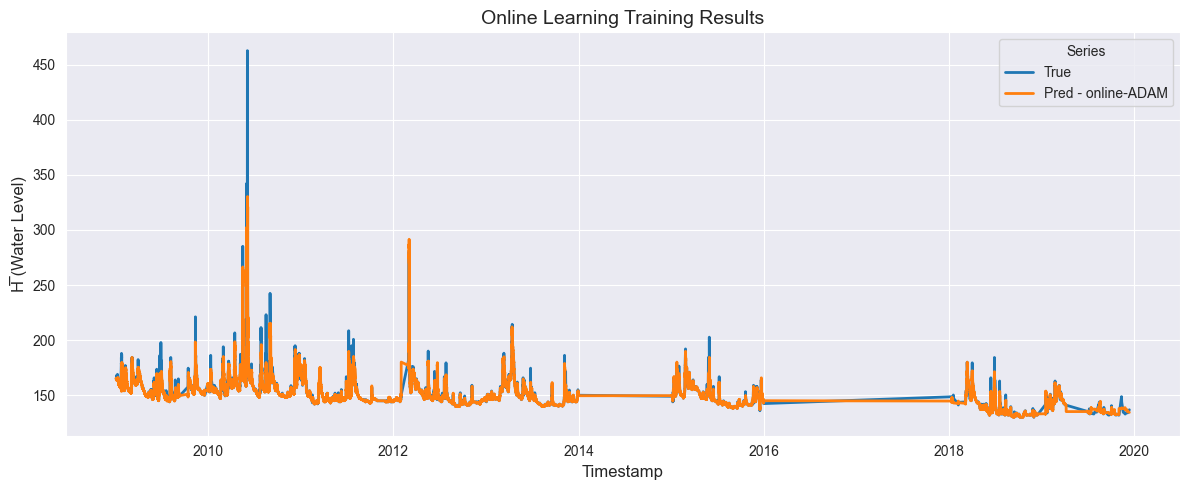

Saved PNG: results/training\Online Learning Training Results.png
Appended metrics to CSV: results/training\Online Learning Training Results.csv


In [4]:
model, optimizer, criterion = build_mlp(LOOKBACK*N_FEATURES, HORIZON)

y_true, y_pred, time_indices, cutom_adam_batch_losses = uf.train_model_online(model, optimizer,criterion,
                                                                              train_ds, train_df,
                                                                              LOOKBACK, HORIZON, BATCH_SIZE)
#training results
uf.calculate_metrics_and_plot({"online-ADAM": (y_true, y_pred, time_indices)}, 
                              plot_title="Online Learning Training Results",
                              export_metrics= True,
                              export_html= True,
                              export_file_name='results/training/Online Learning Training Results')

Testing complete.


============== FINAL COMPARISON ==============
online-ADAM          | RMSE=4.9743 | MAE=1.4029 | R²=0.8128


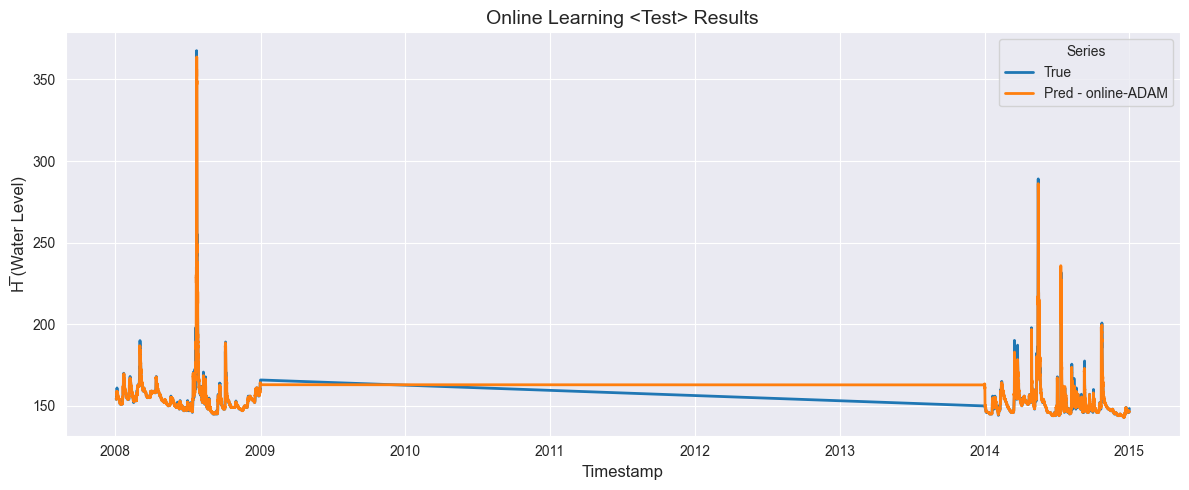

Saved PNG: results/testing/online\Online Learning MLP test.png
Appended metrics to CSV: results/testing/online\Online Learning MLP test.csv
Exported results to CSV: results/testing/predictions_vs_true/online_MLP.csv


In [5]:
# evaluation on test set
y_true_test, y_pred_test, time_indices_test = uf.model_evaluate_with_norm(model,criterion, test_ds, test_df.index,
                                                                 LOOKBACK, HORIZON, BATCH_SIZE)
uf.calculate_metrics_and_plot({"online-ADAM": (y_true_test, y_pred_test, time_indices_test)},
                              plot_title = 'Online Learning <Test> Results',
                              export_metrics= True,
                              export_html= True,
                              export_file_name='results/testing/online/Online Learning MLP test')
# Save predictions to CSV files to be used later in Experiments
uf.export_results_to_csv({"MLP": (y_true_test, y_pred_test,time_indices_test)}, 
                         "results/testing/predictions_vs_true/online")
    

## Testing Always updating
See model behaviour if we allowed it to learn on the fly from the testing data.<br>
**conclusion**<br>
Model's performance metrics went up as we all model to optimize and generalize more. In contarst model ability to adapt in lowered.<br>
We need to investigate more about optimizers and the adaptability, generalization trade-off.


Starting 'online' training with 728 batches...
   Batch 100/728, Loss: 0.101974
   Batch 200/728, Loss: 0.144361
   Batch 300/728, Loss: 0.450452
   Batch 400/728, Loss: 0.152144
   Batch 500/728, Loss: 0.006481
   Batch 600/728, Loss: 0.019839
   Batch 700/728, Loss: 0.013736
   Batch 728/728, Loss: 0.160159
Training complete.


============== FINAL COMPARISON ==============
online-MLP           | RMSE=4.4258 | MAE=1.3657 | R²=0.8518


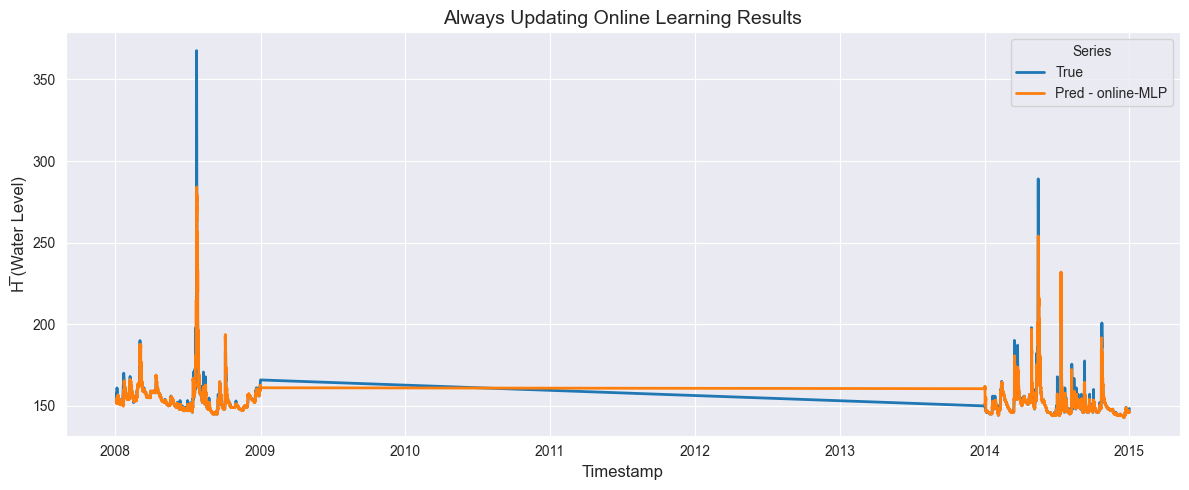

Saved PNG: .\Always Updating Online Learning Results.png


In [6]:
# Testing with always updating 
model, optimizer, criterion = build_mlp(LOOKBACK*N_FEATURES, HORIZON)
y_true, y_pred, time_indices, cutom_adam_batch_losses = uf.train_model_online(model, optimizer,criterion,
                                                                              test_ds, test_df,
                                                                              LOOKBACK, HORIZON, BATCH_SIZE)
#training results
uf.calculate_metrics_and_plot({"online-MLP": (y_true, y_pred, time_indices)}, 
                              plot_title="Always Updating Online Learning Results")